In [1]:
import sys
sys.path.append('/work/lpdi/users/ymiao/code/MFE')
import torch
from dmasif_encoder.protein_surface_encoder import *
from dmasif_encoder.benchmark_models import dMaSIFConv_seg
sys.path.append('/work/lpdi/users/ymiao/code/newcode_0923/atomsurf/')
from atomsurf.tasks.pip_site.data_loader import PIPsiteDataModule,PIPsiteDataset,SurfaceLoader,GraphLoader
from easydict import EasyDict
import yaml
with open("/work/lpdi/users/ymiao/code/MFE/configs/config.yml", 'r') as f:
    dmasifcfg = EasyDict(yaml.safe_load(f))
from hydra import initialize, initialize_config_module, initialize_config_dir, compose
from omegaconf import OmegaConf


with initialize(config_path="./conf/"):
    cfg = compose(config_name="config.yaml")

cfg.data_dir='/work/lpdi/users/ymiao/atom2D/data/DIPS-split/data/'
cfg.loader.num_workers = 10
cfg.loader.batch_size = 1
cfg.loader.pin_memory =True
cfg.cfg_graph.use_esm=True
torch.multiprocessing.set_sharing_strategy('file_system')
torch.set_num_threads(1)

/tmp/ipykernel_298469/48300524.py:16: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="./conf/"):


In [2]:
pipsitepl=PIPsiteDataModule(cfg)

In [3]:
testloader=pipsitepl.test_dataloader()

In [4]:
for batchdata in testloader:
    break


/work/lpdi/users/ymiao/atomsurf_dmasif/lib/python3.8/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/work/lpdi/users/ymiao/atomsurf_dmasif/lib/python3.8/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = elem.storage()._new_shared(numel)
/work/lpdi/users/ymiao/atomsurf_dmasif/lib/python3.8/site-packages/torch_geometric/data/collate.py:145: UserWarning: TypedStorage 

In [5]:
args=dmasifcfg.model.dmasif

In [6]:
conv = dMaSIFConv_seg(args,
            in_channels=22,
            out_channels=16,
            n_layers=2,
            radius=9.0,
        )

In [7]:
from dmasif_encoder.geometry_processing import (
    curvatures,
)

In [15]:
curvature= curvatures(
            batchdata.surface_1.verts,
            triangles= None,
            normals= batchdata.surface_1.vnormals,
            scales=args.curvature_scales,
            batch=batchdata.surface_1.batch,
        )

In [14]:
args.curvature_scales

[1.0, 2.0, 3.0, 5.0, 10.0]

In [16]:
curvature.shape

torch.Size([5371, 10])

In [14]:
import torch.nn as nn
orientation_scores=nn.Sequential(
            nn.Linear(22, 16),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(16, 1),
        )


In [15]:
conv.load_mesh(xyz=batchdata.surface_1.verts,normals=batchdata.surface_1.vnormals,weights=orientation_scores(batchdata.surface_1.x),batch=batchdata.surface_1.batch)

[KeOps] Generating code for Sum_Reduction reduction (with parameters 0) of formula (e*Exp(-(Sum((a-b)**2)*(2-c|d)**2)))*MatVecMult(f,a-b) with a=Var(0,3,1), b=Var(1,3,0), c=Var(2,3,0), d=Var(3,3,1), e=Var(4,1,1), f=Var(5,6,0) ... OK


In [16]:
embed = conv(batchdata.surface_1.x)

[KeOps] Generating code for Sum_Reduction reduction (with parameters 0) of formula (Exp(-(Sum((a-b)**2)*(2-Extract(c,0,3)|d)**2))*ReLU(MatVecMult(e,ReLU(MatVecMult(f,MatVecMult(c,a-b))+g))+h))*i with a=Var(0,3,1), b=Var(1,3,0), c=Var(2,9,0), d=Var(3,3,1), e=Var(4,64,2), f=Var(5,24,2), g=Var(6,8,2), h=Var(7,8,2), i=Var(8,8,1) ... OK


In [18]:
embed.shape

torch.Size([5371, 16])

In [6]:
tmp_vert= batchdata.surface_1.verts.numpy()

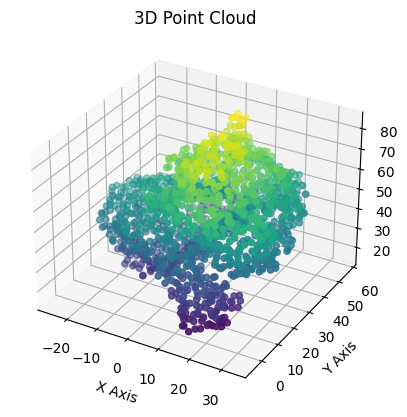

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Generate some random 3D data (example)
num_points = 1000
x = np.random.rand(num_points)  # Random x coordinates
y = np.random.rand(num_points)  # Random y coordinates
z = np.random.rand(num_points)  # Random z coordinates

# Create a figure and a 3D subplot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of 3D point cloud
ax.scatter(tmp_vert[:,0], tmp_vert[:,1], tmp_vert[:,2], c=tmp_vert[:,2], cmap='viridis', marker='o')

# Set plot labels and title
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Point Cloud')

# Show the plot
plt.show()